In [1]:
import numpy as np
import pandas as pd
import re
import string
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack, csr_matrix

from imblearn.over_sampling import SMOTE

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv')
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
print(df.shape)
print(df.dtypes)

(17880, 18)
job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct.round(2)
}).sort_values('missing_%', ascending=False)

missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_%
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


In [5]:
print("Duplicates:", df.duplicated().sum())
df.describe()

Duplicates: 0


,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


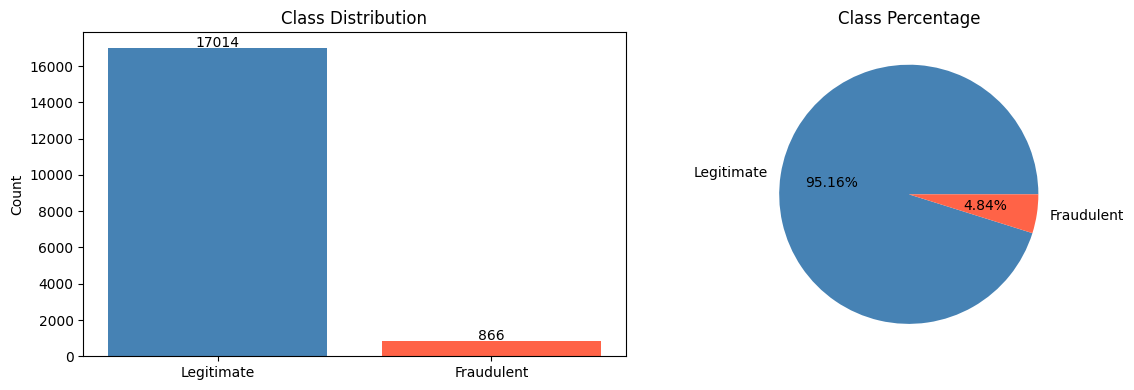

Legitimate: 17014  |  Fraudulent: 866
Imbalance ratio: 19.6:1


In [6]:
counts = df['fraudulent'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraudulent'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center')

axes[1].pie(counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Class Percentage')

plt.tight_layout()
plt.show()

print(f"Legitimate: {counts[0]}  |  Fraudulent: {counts[1]}")
print(f"Imbalance ratio: {round(counts[0]/counts[1], 1)}:1")

The dataset is heavily imbalanced — around 95% legitimate vs 5% fraudulent.
A model that predicts everything as legitimate would still get ~95% accuracy, which is misleading.
This means accuracy alone is not a good metric here.
We need to focus on Recall and F1-score for the fraud class.
We will handle this imbalance later using SMOTE.

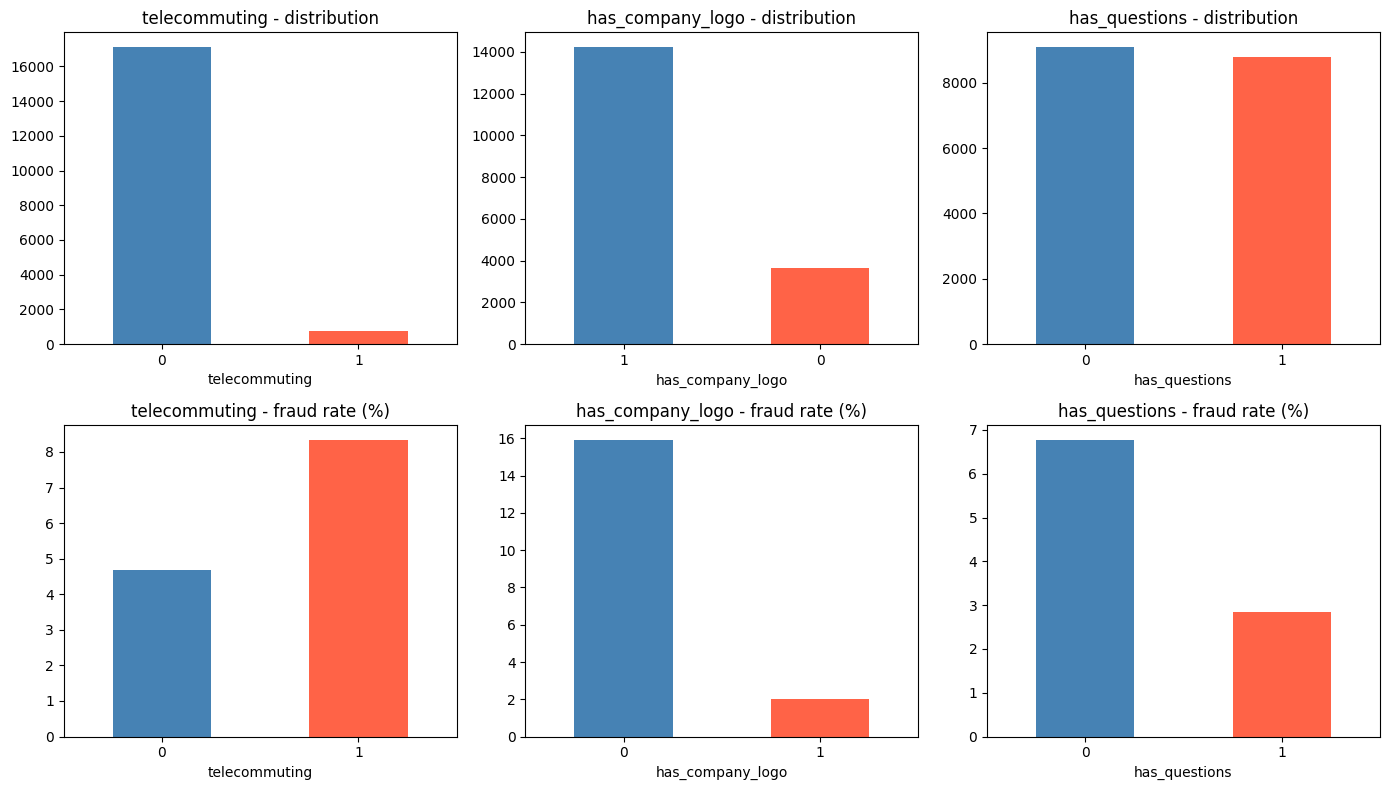

In [7]:
num_cols = ['telecommuting', 'has_company_logo', 'has_questions']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[0, i], color=['steelblue', 'tomato'])
    axes[0, i].set_title(f'{col} - distribution')
    axes[0, i].tick_params(axis='x', rotation=0)

    fraud_rate = df.groupby(col)['fraudulent'].mean() * 100
    fraud_rate.plot(kind='bar', ax=axes[1, i], color=['steelblue', 'tomato'])
    axes[1, i].set_title(f'{col} - fraud rate (%)')
    axes[1, i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

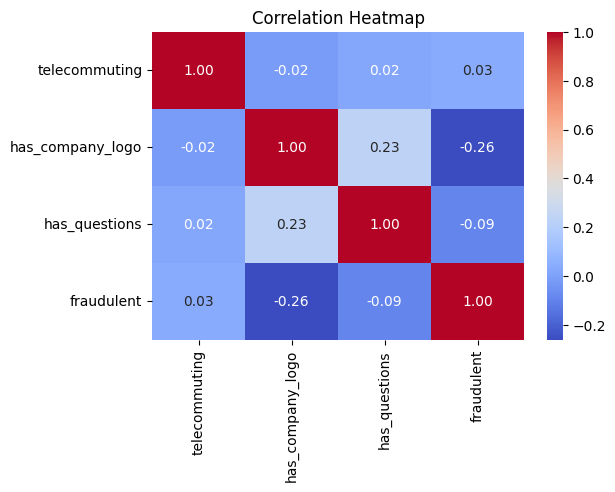

In [8]:
corr_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']

plt.figure(figsize=(6, 4))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

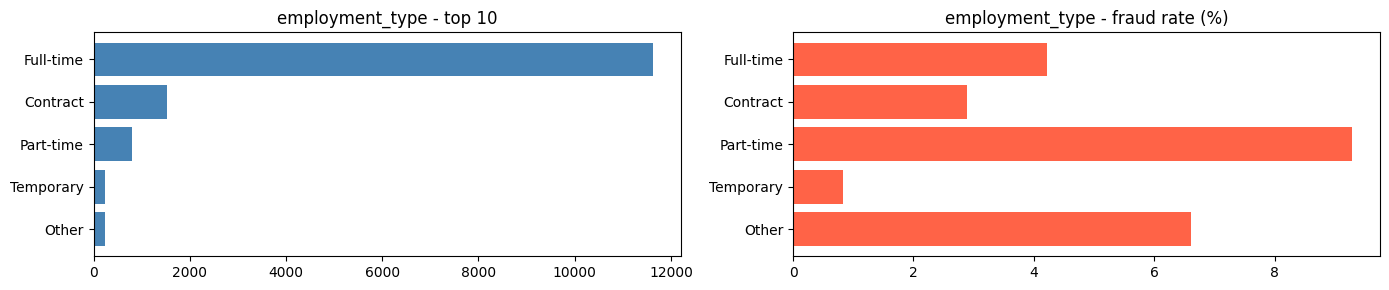

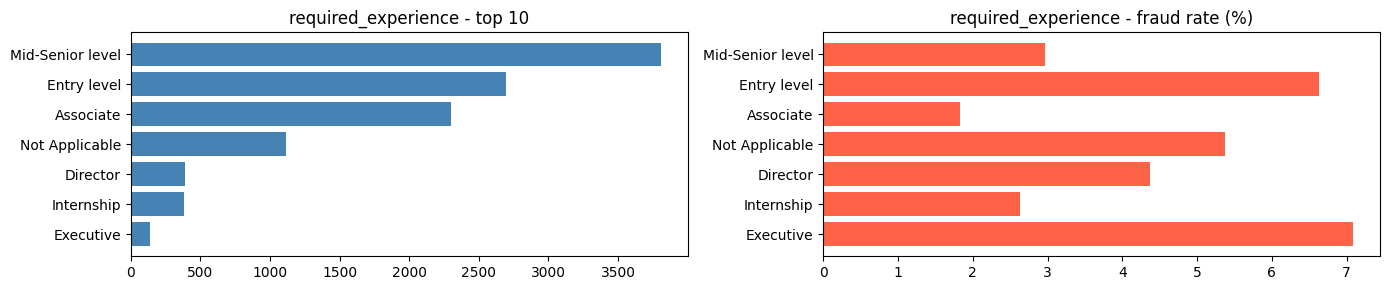

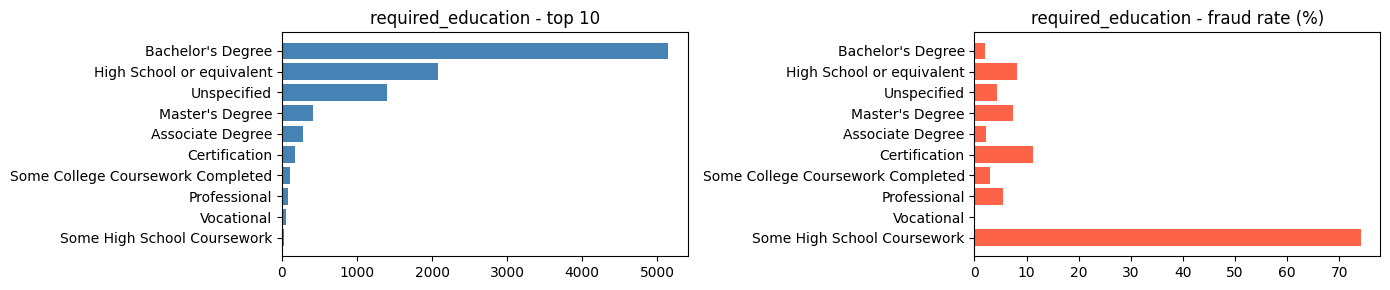

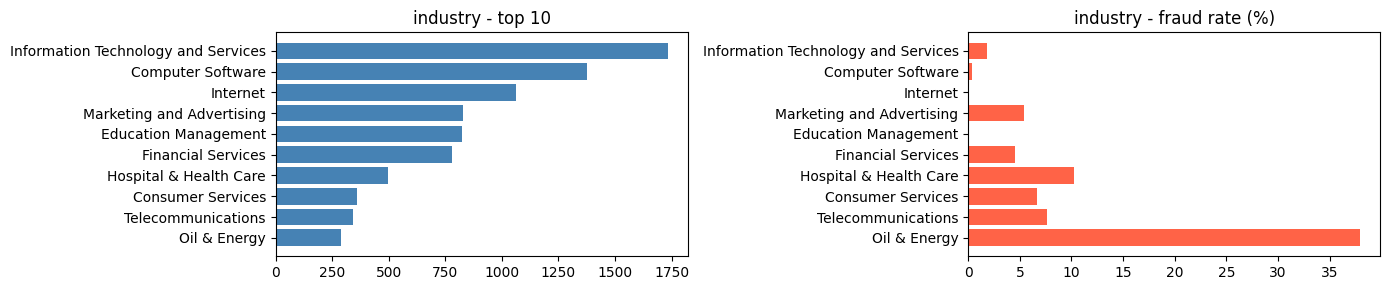

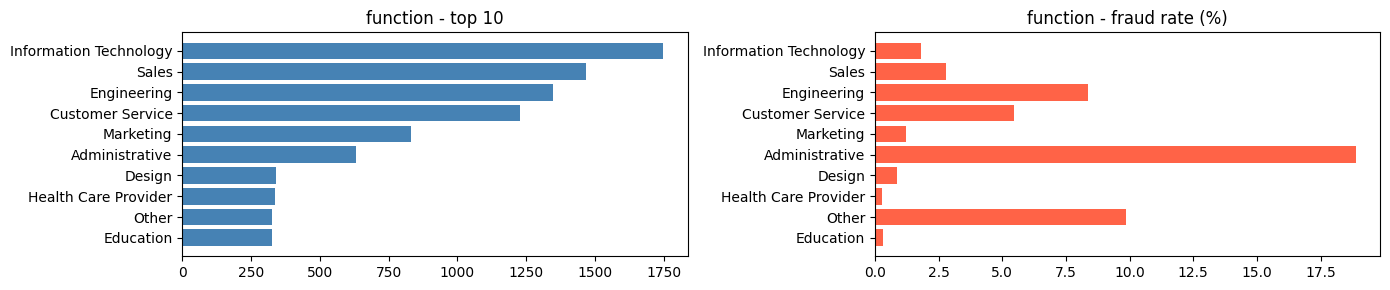

In [9]:
cat_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function']

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))

    top10 = df[col].value_counts().head(10)
    axes[0].barh(top10.index[::-1], top10.values[::-1], color='steelblue')
    axes[0].set_title(f'{col} - top 10')

    fraud_rate = df.groupby(col)['fraudulent'].mean().reindex(top10.index) * 100
    axes[1].barh(fraud_rate.index[::-1], fraud_rate.values[::-1], color='tomato')
    axes[1].set_title(f'{col} - fraud rate (%)')

    plt.tight_layout()
    plt.show()

In [10]:
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
df['combined_text'] = df[text_cols].fillna('').agg(' '.join, axis=1)

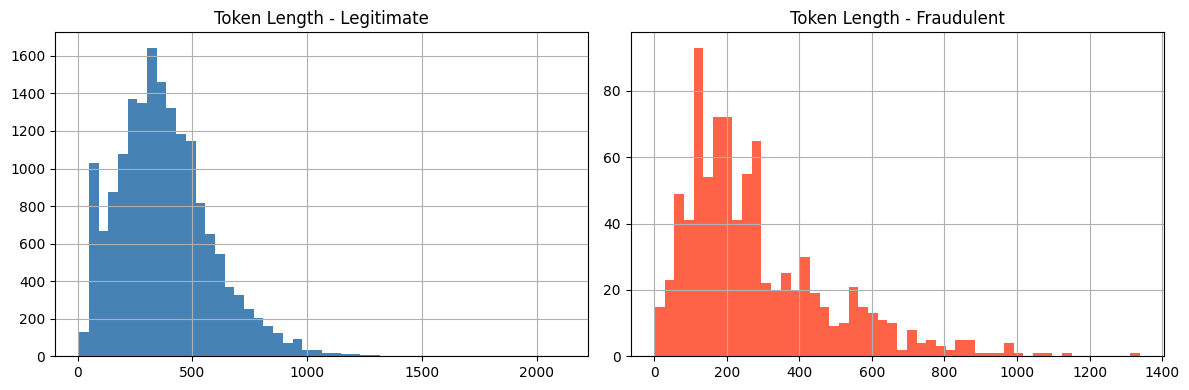

Avg tokens - Legitimate: 379
Avg tokens - Fraudulent: 282


In [11]:
df['token_count'] = df['combined_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['fraudulent'] == 0]['token_count'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Token Length - Legitimate')

df[df['fraudulent'] == 1]['token_count'].hist(bins=50, ax=axes[1], color='tomato')
axes[1].set_title('Token Length - Fraudulent')

plt.tight_layout()
plt.show()

print("Avg tokens - Legitimate:", round(df[df['fraudulent']==0]['token_count'].mean()))
print("Avg tokens - Fraudulent:", round(df[df['fraudulent']==1]['token_count'].mean()))

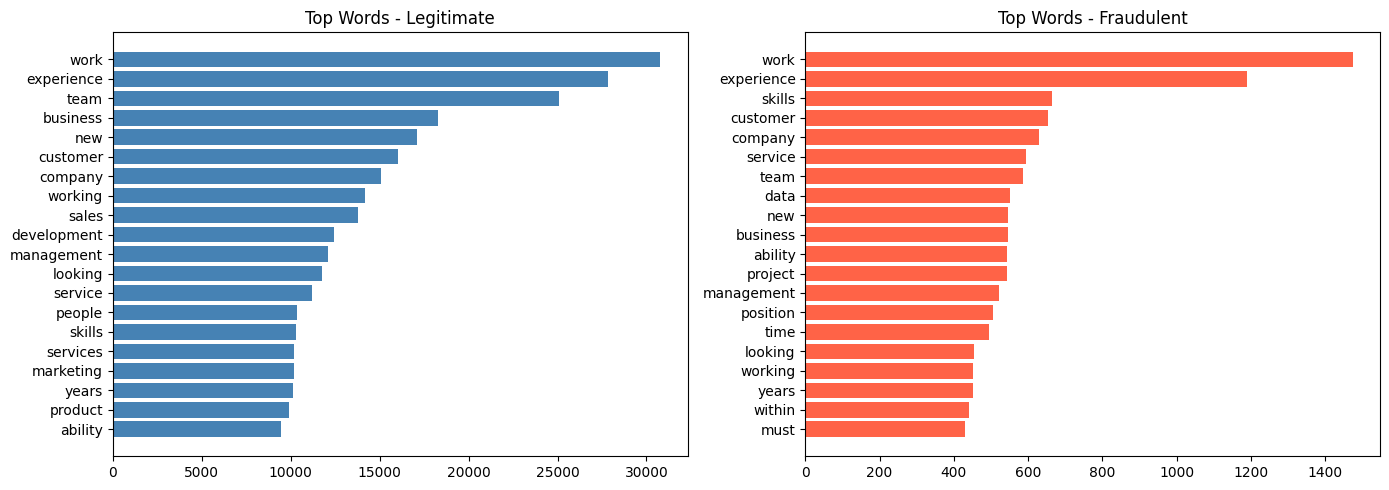

In [12]:
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        tokens = text.lower().split()
        tokens = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 2]
        words.extend(tokens)
    return Counter(words).most_common(n)

legit_words = get_top_words(df[df['fraudulent']==0]['combined_text'])
fraud_words = get_top_words(df[df['fraudulent']==1]['combined_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words, counts = zip(*legit_words)
axes[0].barh(list(words)[::-1], list(counts)[::-1], color='steelblue')
axes[0].set_title('Top Words - Legitimate')

words, counts = zip(*fraud_words)
axes[1].barh(list(words)[::-1], list(counts)[::-1], color='tomato')
axes[1].set_title('Top Words - Fraudulent')

plt.tight_layout()
plt.show()

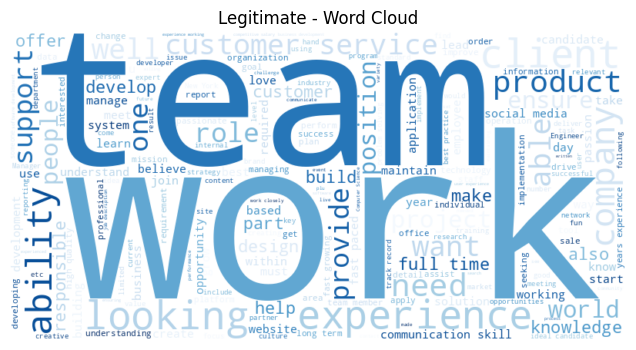

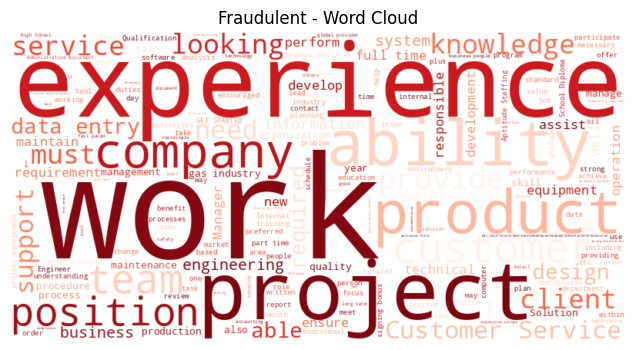

In [13]:
def plot_wordcloud(texts, title, colormap):
    text = ' '.join(texts)
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=colormap, stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

plot_wordcloud(df[df['fraudulent']==0]['combined_text'], 'Legitimate - Word Cloud', 'Blues')
plot_wordcloud(df[df['fraudulent']==1]['combined_text'], 'Fraudulent - Word Cloud', 'Reds')

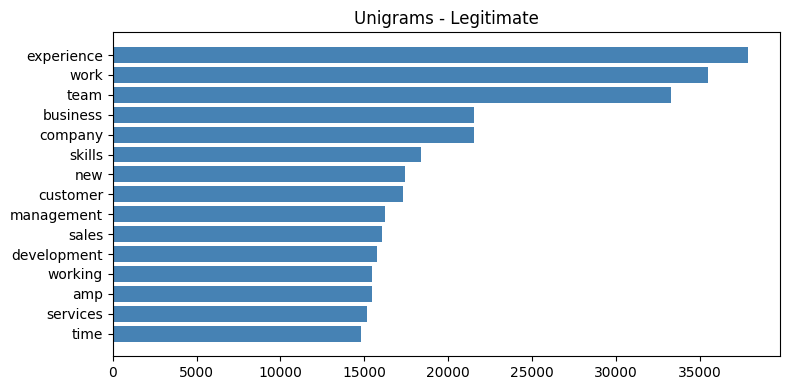

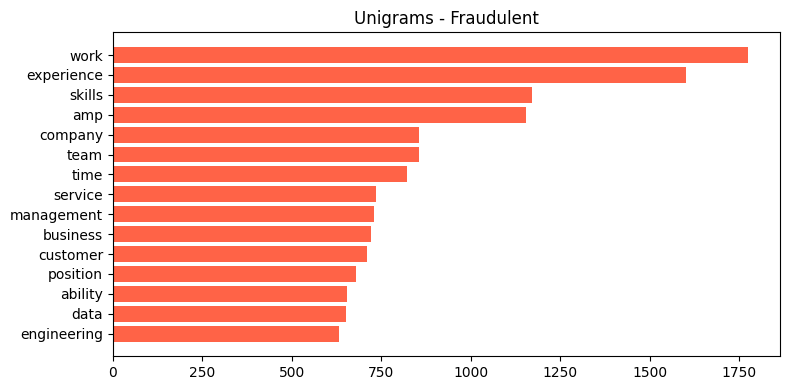

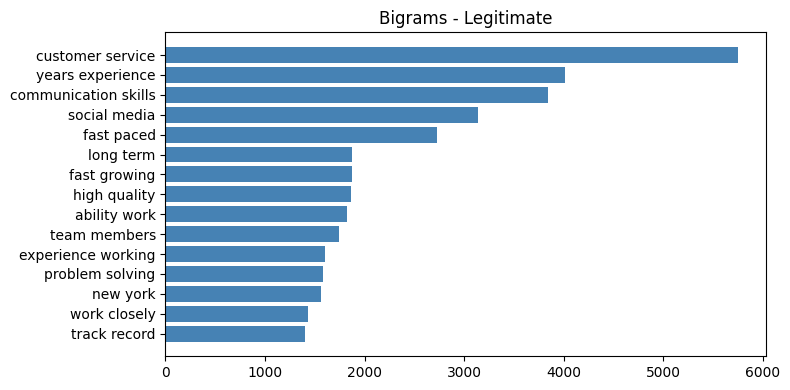

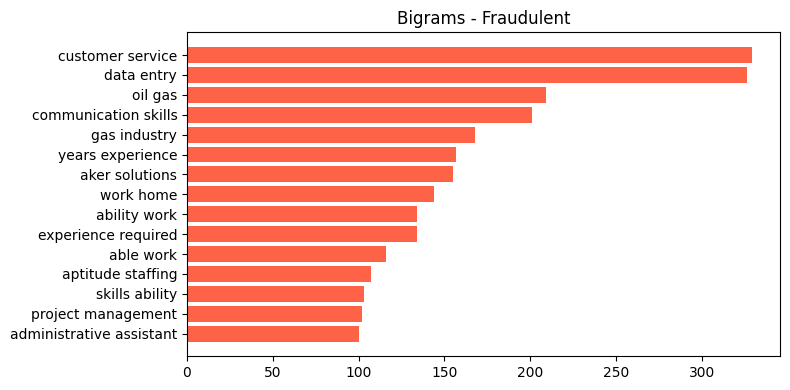

In [14]:
def plot_ngrams(texts, n, title, color):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=5000)
    X = vec.fit_transform(texts)
    freqs = X.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    top = sorted(zip(terms, freqs), key=lambda x: -x[1])[:15]
    words, counts = zip(*top)
    plt.figure(figsize=(8, 4))
    plt.barh(list(words)[::-1], list(counts)[::-1], color=color)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_ngrams(df[df['fraudulent']==0]['combined_text'], 1, 'Unigrams - Legitimate', 'steelblue')
plot_ngrams(df[df['fraudulent']==1]['combined_text'], 1, 'Unigrams - Fraudulent', 'tomato')
plot_ngrams(df[df['fraudulent']==0]['combined_text'], 2, 'Bigrams - Legitimate', 'steelblue')
plot_ngrams(df[df['fraudulent']==1]['combined_text'], 2, 'Bigrams - Fraudulent', 'tomato')

In [15]:
lemmatizer = WordNetLemmatizer()
stop_words_set = set(stopwords.words('english'))

def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words_set and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

In [16]:
df['cleaned_text'] = df['combined_text'].apply(preprocess)

print("Before:", df['combined_text'].iloc[1][:200])
print("After: ", df['cleaned_text'].iloc[1][:200])

Before: Customer Service - Cloud Video Production 90 Seconds, the worlds Cloud Video Production Service.90 Seconds is the worlds Cloud Video Production Service enabling brands and agencies to get high quality
After:  customer service cloud video production second world cloud video production service second world cloud video production service enabling brand agency get high quality online video content shot produce


In [17]:
df['word_count']      = df['cleaned_text'].apply(lambda x: len(x.split()))
df['char_count']      = df['cleaned_text'].apply(len)
df['avg_word_len']    = df['cleaned_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
df['unique_word_ratio'] = df['cleaned_text'].apply(
    lambda x: len(set(x.split())) / (len(x.split()) + 1e-5))

df[['word_count', 'char_count', 'avg_word_len', 'unique_word_ratio']].describe()

,word_count,char_count,avg_word_len,unique_word_ratio
count,17880.000000,17880.000000,17880.000000,17880.000000
mean,232.381600,1989.344239,7.570507,0.749923
std,126.531617,1092.555312,0.671711,0.092457
min,2.000000,14.000000,4.500000,0.216867
25%,139.000000,1157.000000,7.154341,0.693431
50%,220.000000,1891.000000,7.562500,0.756637
75%,305.000000,2604.000000,7.935329,0.813559
max,1359.000000,11484.000000,27.461538,1.000000


In [18]:
from sklearn.preprocessing import StandardScaler

num_features = ['word_count', 'char_count', 'avg_word_len', 'unique_word_ratio',
                'telecommuting', 'has_company_logo', 'has_questions']

X_text = df['cleaned_text']
X_num  = df[num_features].values
y      = df['fraudulent']

# stratified split — preserves class distribution in both train and test
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y, test_size=0.2, random_state=42, stratify=y)

# scale numerical features — fit on train only to prevent data leakage
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled  = scaler.transform(X_num_test)

# fit TF-IDF on train only
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=15000,
                        min_df=2, sublinear_tf=True)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test  = tfidf.transform(X_text_test)

# combine TF-IDF + scaled numerical features
X_train = hstack([X_tfidf_train, csr_matrix(X_num_train_scaled)])
X_test  = hstack([X_tfidf_test,  csr_matrix(X_num_test_scaled)])

# apply SMOTE to balance training set — only on train, never on test
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE :", Counter(y_train_res))
print("\nTrain size  :", X_train_res.shape)
print("Test size   :", X_test.shape)

Before SMOTE: Counter({0: 13611, 1: 693})
After SMOTE : Counter({0: 13611, 1: 13611})

Train size  : (27222, 15007)
Test size   : (3576, 15007)


Skewness:
word_count           0.870
char_count           0.896
avg_word_len         3.418
unique_word_ratio   -0.483
telecommuting        4.512
has_company_logo    -1.464
has_questions        0.033
dtype: float64


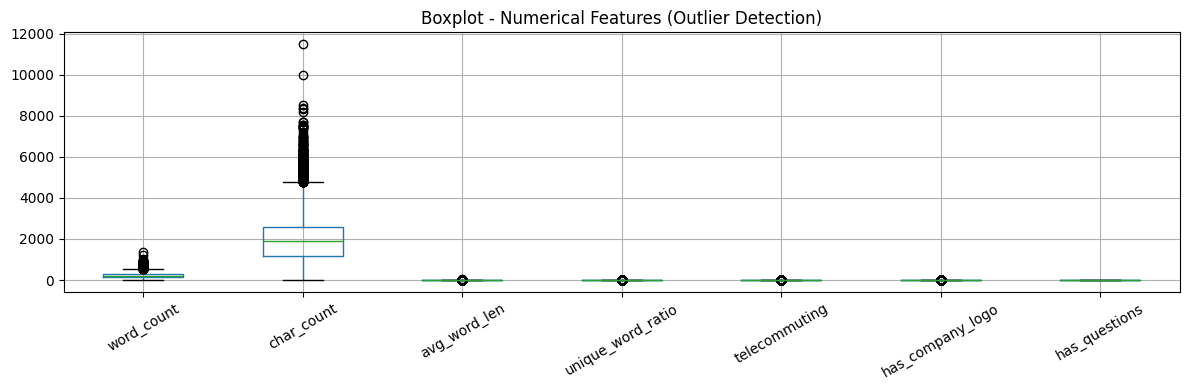

In [19]:
# skewness of handcrafted features
print("Skewness:")
print(df[num_features].skew().round(3))

# boxplot to visualize outliers
plt.figure(figsize=(12, 4))
df[num_features].boxplot()
plt.xticks(rotation=30)
plt.title('Boxplot - Numerical Features (Outlier Detection)')
plt.tight_layout()
plt.show()

Class ratio  neg=13611  pos=13611  scale=1.00


🔄  Training: XGBoost (GPU)
    Fold 1/5 — F1: 0.6782
    Fold 2/5 — F1: 0.6748
    Fold 3/5 — F1: 0.7670
    Fold 4/5 — F1: 0.6056
    Fold 5/5 — F1: 0.6797
    ✅ CV F1: 0.6811 ± 0.0512

🔄  Training: CatBoost (GPU)
    Fold 1/5 — F1: 0.9923
    Fold 2/5 — F1: 0.9894
    Fold 3/5 — F1: 0.9874
    Fold 4/5 — F1: 0.9907
    Fold 5/5 — F1: 0.9885
    ✅ CV F1: 0.9897 ± 0.0017

📊  TEST SET EVALUATION

──────────────────────────────────────────────────
  Model       : XGBoost (GPU)
  CV F1       : 0.6811 ± 0.0512
  ROC-AUC     : 0.5434
  PR-AUC      : 0.0527   ← better metric for imbalanced data
  F1 Score    : 0.1002
  Precision   : 0.0528
  Recall      : 0.9884

  Classification Report:

              precision    recall  f1-score   support

        Real       0.99      0.10      0.18      3403
        Fake       0.05      0.99      0.10       173

    accuracy                           0.14      3576
   macro avg       0.52      0.54      0.1

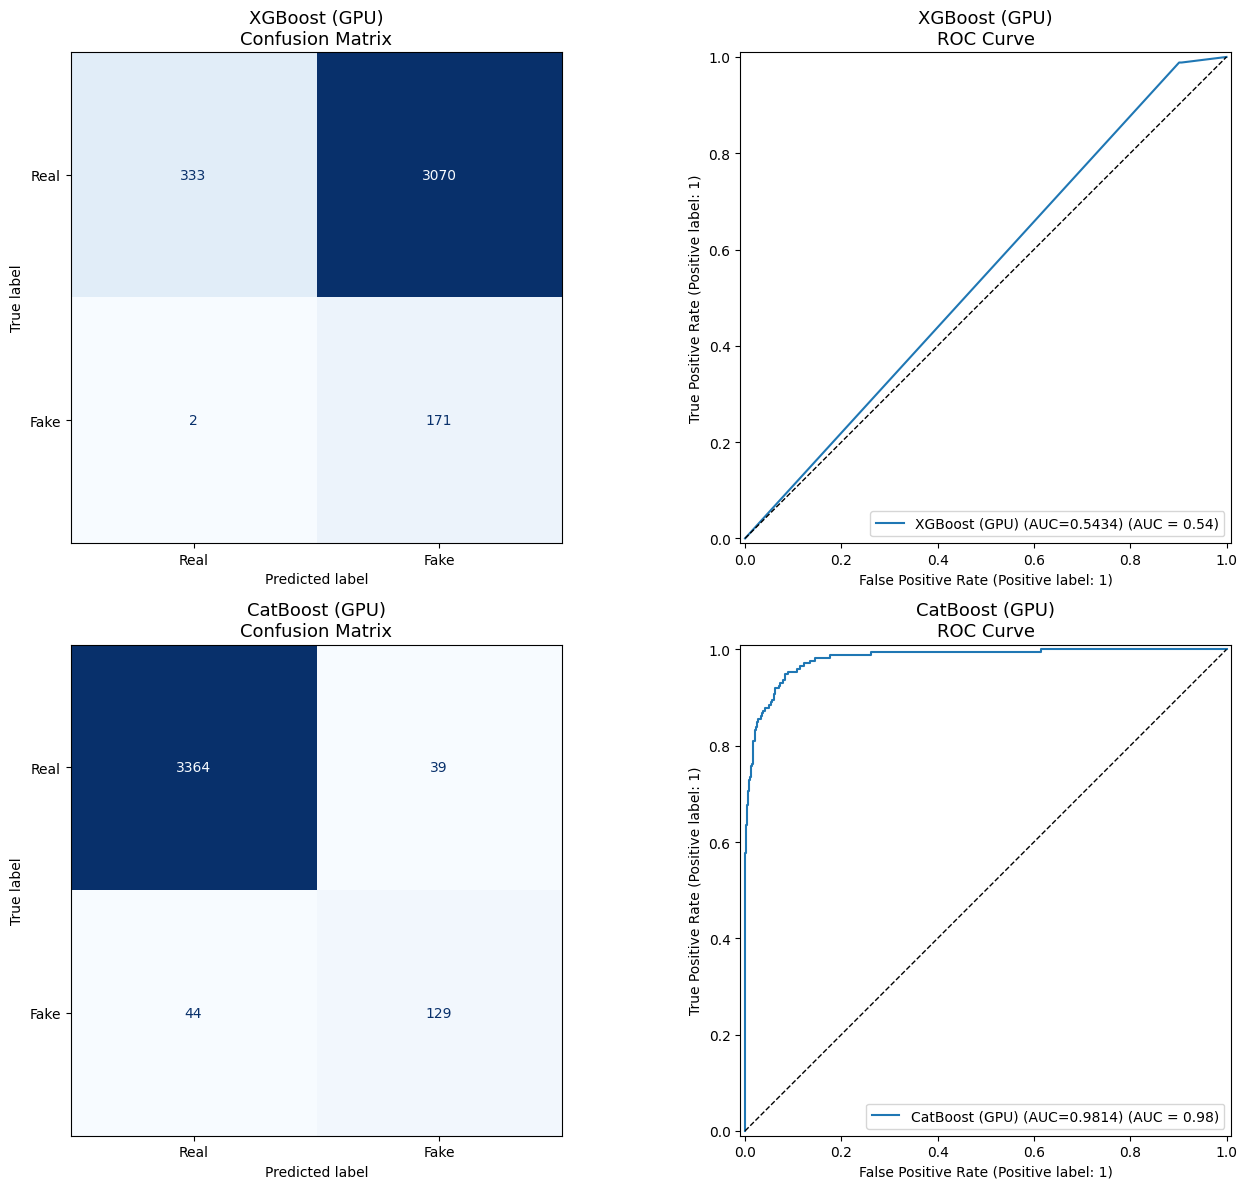


📊  Plots saved → /kaggle/working/evaluation_plots.png

Model                       ROC-AUC    PR-AUC        F1   Precision    Recall
------------------------------------------------------------
XGBoost (GPU)                0.5434    0.0527    0.1002      0.0528    0.9884
CatBoost (GPU)               0.9814    0.8529    0.7566      0.7679    0.7457

💾  Saving models...
    ✅ XGBoost  → /kaggle/working/xgboost_model.json
    ✅ CatBoost → /kaggle/working/catboost_model.cbm
    ✅ All models dict → /kaggle/working/all_models.pkl

🎉  Done! Models saved to /kaggle/working/


In [23]:
import os, warnings, logging, contextlib, joblib, numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, precision_score, recall_score,
    average_precision_score, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt
from xgboost  import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier

# ── Silence noise ─────────────────────────────────────────────────────────────
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
warnings.filterwarnings("ignore")
logging.getLogger("catboost").setLevel(logging.ERROR)

@contextlib.contextmanager
def suppress_c_noise():
    with open(os.devnull, 'w') as devnull:
        old_out, old_err = os.dup(1), os.dup(2)
        os.dup2(devnull.fileno(), 1)
        os.dup2(devnull.fileno(), 2)
        try:    yield
        finally:
            os.dup2(old_out, 1); os.dup2(old_err, 2)
            os.close(old_out);   os.close(old_err)

# ── Class imbalance ───────────────────────────────────────────────────────────
neg, pos = np.bincount(y_train_res)
scale    = neg / pos
print(f"Class ratio  neg={neg}  pos={pos}  scale={scale:.2f}")

# ── Models ────────────────────────────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale,
    eval_metric      = 'logloss',
    device           = 'cuda',
    tree_method      = 'hist',
    random_state     = 42,
)

cb_model = CatBoostClassifier(
    iterations         = 500,
    learning_rate      = 0.05,
    depth              = 6,
    auto_class_weights = 'Balanced',
    eval_metric        = 'F1',
    task_type          = 'GPU',
    devices            = '0',
    random_seed        = 42,
    verbose            = 0,
)

models = {
    'XGBoost (GPU)' : xgb_model,
    'CatBoost (GPU)': cb_model,
}

# ── CV + Training ─────────────────────────────────────────────────────────────
cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
trained      = {}
cv_results   = {}

print("\n" + "="*60)
for name, model in models.items():
    print(f"\n🔄  Training: {name}")
    noisy = 'CatBoost' in name

    f1_scores = []
    for i, (tr_idx, val_idx) in enumerate(cv.split(X_train_res, y_train_res)):
        X_tr, X_val = X_train_res[tr_idx], X_train_res[val_idx]
        y_tr, y_val = y_train_res[tr_idx],  y_train_res[val_idx]
        ctx = suppress_c_noise() if noisy else contextlib.nullcontext()
        with ctx:
            model.fit(X_tr, y_tr)
        fold_f1 = f1_score(y_val, model.predict(X_val))
        f1_scores.append(fold_f1)
        print(f"    Fold {i+1}/5 — F1: {fold_f1:.4f}")

    ctx = suppress_c_noise() if noisy else contextlib.nullcontext()
    with ctx:
        model.fit(X_train_res, y_train_res)

    trained[name]    = model
    cv_results[name] = (np.mean(f1_scores), np.std(f1_scores))
    print(f"    ✅ CV F1: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

# ── Evaluation on test set ────────────────────────────────────────────────────
print("\n" + "="*60)
print("📊  TEST SET EVALUATION")
print("="*60)

fig, axes = plt.subplots(len(trained), 2, figsize=(14, 6 * len(trained)))
if len(trained) == 1:
    axes = [axes]

eval_results = {}

for idx, (name, model) in enumerate(trained.items()):
    y_pred      = model.predict(X_test)
    y_proba     = model.predict_proba(X_test)[:, 1]

    # ── Metrics ───────────────────────────────────────────────────────────────
    roc_auc  = roc_auc_score(y_test, y_proba)
    pr_auc   = average_precision_score(y_test, y_proba)
    f1       = f1_score(y_test, y_pred)
    precision= precision_score(y_test, y_pred)
    recall   = recall_score(y_test, y_pred)
    cv_f1, cv_std = cv_results[name]

    eval_results[name] = {
        'ROC-AUC' : roc_auc,
        'PR-AUC'  : pr_auc,
        'F1'      : f1,
        'Precision': precision,
        'Recall'  : recall,
    }

    print(f"\n{'─'*50}")
    print(f"  Model       : {name}")
    print(f"  CV F1       : {cv_f1:.4f} ± {cv_std:.4f}")
    print(f"  ROC-AUC     : {roc_auc:.4f}")
    print(f"  PR-AUC      : {pr_auc:.4f}   ← better metric for imbalanced data")
    print(f"  F1 Score    : {f1:.4f}")
    print(f"  Precision   : {precision:.4f}")
    print(f"  Recall      : {recall:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

    # ── Confusion Matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Real', 'Fake']).plot(
        ax=axes[idx][0], colorbar=False, cmap='Blues'
    )
    axes[idx][0].set_title(f"{name}\nConfusion Matrix", fontsize=13)

    # ── ROC Curve ─────────────────────────────────────────────────────────────
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[idx][1],
                                     name=f"{name} (AUC={roc_auc:.4f})")
    axes[idx][1].plot([0,1],[0,1],'k--', linewidth=1)
    axes[idx][1].set_title(f"{name}\nROC Curve", fontsize=13)

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊  Plots saved → /kaggle/working/evaluation_plots.png")

# ── Final comparison table ────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"{'Model':<25} {'ROC-AUC':>9} {'PR-AUC':>9} {'F1':>9} {'Precision':>11} {'Recall':>9}")
print("-"*60)
for name, m in eval_results.items():
    print(f"{name:<25} {m['ROC-AUC']:>9.4f} {m['PR-AUC']:>9.4f} {m['F1']:>9.4f} {m['Precision']:>11.4f} {m['Recall']:>9.4f}")
print("="*60)

# ── Save models ───────────────────────────────────────────────────────────────
print("\n💾  Saving models...")

trained['XGBoost (GPU)'].save_model('/kaggle/working/xgboost_model.json')
print("    ✅ XGBoost  → /kaggle/working/xgboost_model.json")

trained['CatBoost (GPU)'].save_model('/kaggle/working/catboost_model.cbm')
print("    ✅ CatBoost → /kaggle/working/catboost_model.cbm")

# Save full trained dict with joblib (includes preprocessors if needed)
joblib.dump(trained, '/kaggle/working/all_models.pkl')
print("    ✅ All models dict → /kaggle/working/all_models.pkl")

print("\n🎉  Done! Models saved to /kaggle/working/")

# ── Load back (example) ───────────────────────────────────────────────────────
# xgb_loaded = XGBClassifier(); xgb_loaded.load_model('/kaggle/working/xgboost_model.json')
# cb_loaded  = CatBoostClassifier(); cb_loaded.load_model('/kaggle/working/catboost_model.cbm')
# all_loaded = joblib.load('/kaggle/working/all_models.pkl')